In [ ]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
from PIL import Image
import numpy as np
#...

In [ ]:
!wget https://www.dropbox.com/s/qii26wuxcbxw169/images.npy
!wget https://www.dropbox.com/s/gstpamhin8rlhlg/masks.npy

--2024-05-28 17:38:15--  https://www.dropbox.com/s/qii26wuxcbxw169/images.npy
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:6019:18::a27d:412
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /scl/fi/6j8ae3xo0yispw99p54pr/images.npy?rlkey=8pjgusrn763ev068rk81vzigy [following]
--2024-05-28 17:38:15--  https://www.dropbox.com/scl/fi/6j8ae3xo0yispw99p54pr/images.npy?rlkey=8pjgusrn763ev068rk81vzigy
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce5d17db9b7f42616e70758c0b6.dl.dropboxusercontent.com/cd/0/inline/CTwILBPYx2PQUs4KsSgcjUqsza9naU6cTNKjOyARDx0pAbvLUnYzENbS5eVK6fjV8dRp7HGBlERNP_IqkdCAIaZA3QsO_iHDZODurz3oMHeGjfYYjAd7bktoCatGqt55Q-0/file# [following]
--2024-05-28 17:38:16--  https://uce5d17db9b7f42616e70758c0b6.dl.dropboxusercontent.com/cd/0/inline/CTwILBPYx2PQUs4KsSgcjUqsza9naU6cTNKjOyARDx0pAbvLUnY

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = 'drive/MyDrive/'

Mounted at /content/drive


In [ ]:
!pip install einops
from einops import rearrange

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 1.8 MB/s eta 0:00:00


In [ ]:
images=np.load("images.npy")
images=images.astype('float32')
print("imgs", images.shape)
## Crop 512
images=images[:,0:512,0:512,:]
print("imgs", images.shape)

masks=np.load("masks.npy")
masks=masks.astype('float32')
print("maks", masks.shape)
## Crop 512
masks=masks[:,0:512,0:512]
masks = np.expand_dims(masks, axis=-1)
print("imgs", masks.shape)


imgs (20, 584, 584, 3)
imgs (20, 512, 512, 3)
maks (20, 584, 584)
imgs (20, 512, 512, 1)


In [ ]:
# TODO: Dataset
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch

class SegmenDataset(Dataset):
    def __init__(self, imgs, masks, transform = None):
        self.data = imgs
        self.targets = masks
        self.transform = transform


    def __getitem__(self, index):
        x = torch.tensor(self.data[index])
        y = torch.tensor(self.targets[index])

        if self.transform:
            x_y = torch.cat([x, y], dim=-1).numpy()/255
            x_y_trans = self.transform(x_y)
            x = x_y_trans[:3,...]
            y = x_y_trans[3:,...]
        return x, y


    def __len__(self):
        return len(self.data)

In [ ]:
from torchvision.transforms import v2
from torchvision import transforms
trans = transforms.Compose([
    transforms.ToTensor(),
    # v2.RandomHorizontalFlip(0.5),
    v2.RandomAffine(degrees=1, translate=(0.01, 0.01))
])

In [ ]:
lr = float('1e-3')
epochs = 500
batch_size = 2

In [ ]:
train_set = SegmenDataset(images, masks, trans)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)

torch.Size([3, 512, 512])


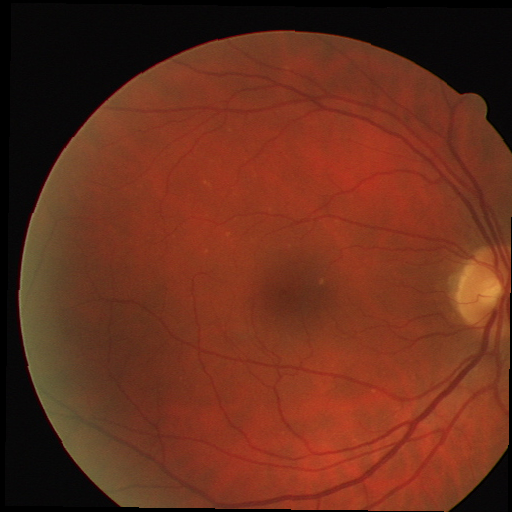

In [ ]:
a, b = train_set[7]
print(a.shape)
orig = a.cpu().numpy()
orig = rearrange(orig, ' c h w -> h w c')
orig *=255
Image.fromarray(orig.astype(np.uint8))


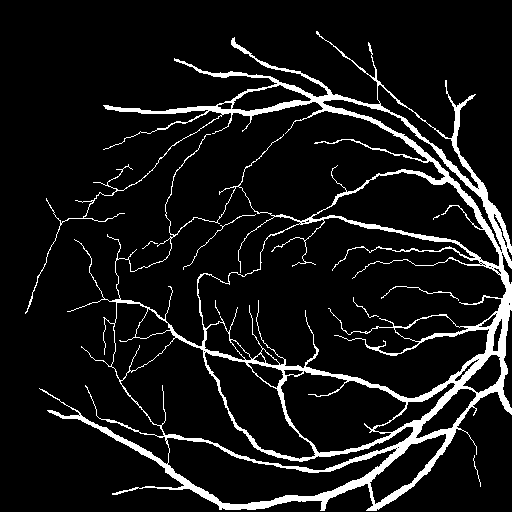

In [ ]:
l_orig = b.cpu().numpy()
l_orig = rearrange(l_orig, ' c h w -> h w c')
l_orig *=255
l_orig = np.squeeze(l_orig, axis=2)
Image.fromarray(l_orig.astype(bool))

In [ ]:
# TODO: implement U-Net
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv_block = nn.Sequential(
          nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
          nn.BatchNorm2d(out_c),
          nn.ReLU(),
          nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
          nn.BatchNorm2d(out_c),
          nn.ReLU()
        )


    def forward(self, inputs):
        return self.conv_block(inputs)


class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = ConvBlock(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)

        return x, p


class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        self.conv = ConvBlock(2*out_c, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)
        x = torch.cat([x, skip], axis=1)
        x = self.conv(x)
        return x


class UNET(nn.Module):
    def __init__(self):
        super().__init__()

        self.eb_1 = EncoderBlock(3, 64)
        self.eb_2 = EncoderBlock(64, 128)
        self.eb_3 = EncoderBlock(128, 256)
        self.eb_4 = EncoderBlock(256, 512)

        self.cb = ConvBlock(512, 1024)

        self.db_1 = DecoderBlock(1024, 512)
        self.db_2 = DecoderBlock(512, 256)
        self.db_3 = DecoderBlock(256, 128)
        self.db_4 = DecoderBlock(128, 64)

        self.outputs = nn.Conv2d(64, 1, kernel_size=1, padding=0)

    def forward(self, inputs):

        s1, p1 = self.eb_1(inputs)
        s2, p2 = self.eb_2(p1)
        s3, p3 = self.eb_3(p2)
        s4, p4 = self.eb_4(p3)

        b = self.cb(p4)

        d1 = self.db_1(b, s4)
        d2 = self.db_2(d1, s3)
        d3 = self.db_3(d2, s2)
        d4 = self.db_4(d3, s1)

        out = self.outputs(d4)

        return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNET()
model.to(device)

UNET(
  (eb_1): EncoderBlock(
    (conv): ConvBlock(
      (conv_block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (eb_2): EncoderBlock(
    (conv): ConvBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

In [ ]:
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-3, momentum = 0.99)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, min_lr=0.000001, patience=25)

In [ ]:
import time
min_loss = 100000
early_stp = 0
for epoch in range(epochs):

    running_loss = 0.0
    start = time.time()
    for i, data in enumerate(train_loader, 0):

        inputs, labels = data[0].to(device), data[1].to(device)
        # zero the parameter gradients
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(torch.sigmoid(outputs), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if min_loss > running_loss:
        min_loss = running_loss
        torch.save(model.state_dict(), f'{drive_path}unet.pt')
        early_stp = 0
    else:
        early_stp += 1

    if early_stp >= 75:
        break



    scheduler.step(running_loss)
    end = time.time()
    print(f'epoch: {epoch+1} ({end-start:.2f}) -- loss: {running_loss / len(train_loader):.4f} -- ETA: {(end-start)*(epochs-epoch):.2f}\n')


epoch: 1 (5.92) -- loss: 0.3608 -- ETA: 2960.04

epoch: 2 (6.44) -- loss: 0.3341 -- ETA: 3212.41

epoch: 3 (5.65) -- loss: 0.2940 -- ETA: 2815.35

epoch: 4 (5.46) -- loss: 0.2542 -- ETA: 2714.90

epoch: 5 (5.65) -- loss: 0.2231 -- ETA: 2801.07

epoch: 6 (5.55) -- loss: 0.1985 -- ETA: 2746.65

epoch: 7 (5.66) -- loss: 0.1808 -- ETA: 2795.93

epoch: 8 (5.46) -- loss: 0.1671 -- ETA: 2691.25

epoch: 9 (5.41) -- loss: 0.1557 -- ETA: 2663.91

epoch: 10 (5.44) -- loss: 0.1456 -- ETA: 2671.25

epoch: 11 (5.43) -- loss: 0.1401 -- ETA: 2659.46

epoch: 12 (5.57) -- loss: 0.1365 -- ETA: 2722.64

epoch: 13 (5.35) -- loss: 0.1339 -- ETA: 2610.90

epoch: 14 (5.47) -- loss: 0.1314 -- ETA: 2662.91

epoch: 15 (5.04) -- loss: 0.1324 -- ETA: 2450.70

epoch: 16 (5.42) -- loss: 0.1291 -- ETA: 2629.50

epoch: 17 (5.08) -- loss: 0.1298 -- ETA: 2460.29

epoch: 18 (5.45) -- loss: 0.1266 -- ETA: 2633.00

epoch: 19 (5.51) -- loss: 0.1241 -- ETA: 2653.45

epoch: 20 (5.13) -- loss: 0.1241 -- ETA: 2469.64

epoch: 21

torch.Size([3, 512, 512])
torch.Size([1, 1, 512, 512])
torch.Size([512, 512, 1])
(512, 512, 1)
(512, 512)


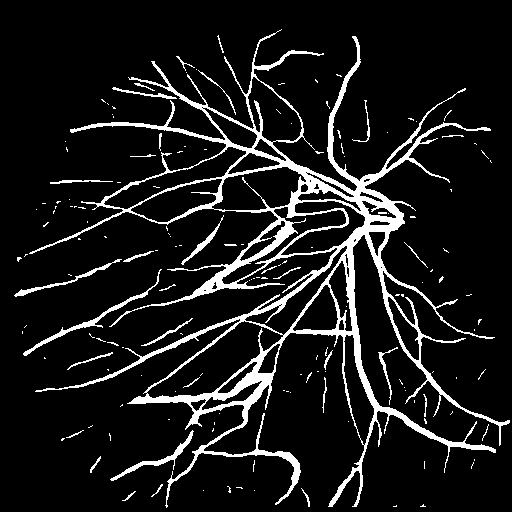

In [ ]:
model.load_state_dict(torch.load(f'{drive_path}unet.pt',map_location=torch.device('cpu')))
data = train_set[2]
inputs, labels = data[0].to(device), data[1].to(device)

with torch.no_grad():
    print(inputs.shape)
    segmen = torch.sigmoid(model(inputs.unsqueeze(dim=0)))>0.5
    print(segmen.shape)
    segmen = rearrange(segmen, 'b c h w -> b h w c')
    segmen = segmen.squeeze(dim=0)
    print(segmen.shape)
    segmen = segmen.cpu().numpy()
    print(segmen.shape)
    segmen = np.squeeze(segmen, axis=2)
    print(segmen.shape)

Image.fromarray((segmen*255).astype(np.uint8))

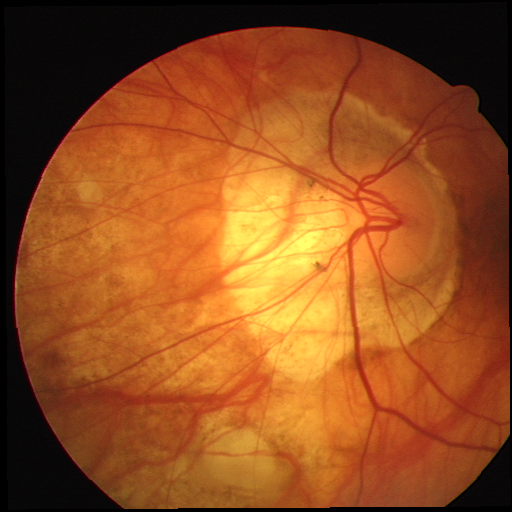

In [ ]:
orig = inputs.cpu().numpy()
orig = rearrange(orig, ' c h w -> h w c')
orig *=255
Image.fromarray(orig.astype(np.uint8))

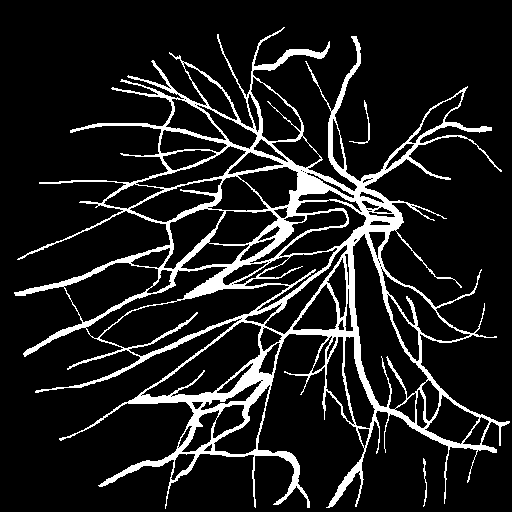

In [ ]:
l_orig = labels.cpu().numpy()
l_orig = rearrange(l_orig, ' c h w -> h w c')
l_orig *=255
l_orig = np.squeeze(l_orig, axis=2)
Image.fromarray(l_orig.astype(np.uint8))